## 17. Orbits

Consider a solar system that contains only the sun, earth, and Jupiter.  Calculate the orbit of the earth, going forward as many years as your computing power allows.  
How accurate is the calculation?
Calculate the precession of the earth's orbit, as well as the change in the eccentricity as a function of time.

We go into the cm frame with the equations:$$
\begin {align}
M_e\vec{x_e'}+M_s\vec{x_s'}+M_j\vec{x_j'}&=(M_e+M_s+M_j)\vec{x_{\rm{cm}}'}\rightarrow\vec{x_{\rm{cm}}'}=\frac{M_e\vec{x_e'}+M_j\vec{x_j'}}{M_e+M_s+M_j}\\
\vec{x_e}&=\vec{x_e'}-\vec{x_{\rm{cm}}'}\\
\vec{x_s}&=-\vec{x_{\rm{cm}}'}\\
\vec{x_j}&=\vec{x_j'}-\vec{x_{\rm{cm}}'}\\
M_e\vec{v_e'}+M_s\vec{v_s'}+M_j\vec{v_j'}&=(M_e+M_s+M_j)\vec{v_{\rm{cm}}'}\rightarrow\vec{v_{\rm{cm}}'}=\frac{M_e\vec{v_e'}+M_j\vec{v_j'}}{M_e+M_s+M_j}\\
\vec{v_e}&=\vec{v_e'}-\vec{v_{\rm{cm}}'}\\
\vec{v_s}&=-\vec{v_{\rm{cm}}'}\\
\vec{v_j}&=\vec{v_j'}-\vec{v_{\rm{cm}}'}\\
\end {align}
$$

Here the primed variables refer to vectors in the coordinate system where the center of the sun is the origin, so $\vec{x_s'}=0$, and the unprimed to cm system.  The subscripts s and e refer to the sun and the earth, x is a position vector, v a velocity vector, and M are masses. 


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time,pickle

run=True #True to recalculate, false to read a saved calculation
#all numbers below from Horizons https://ssd.jpl.nasa.gov/horizons/app.html#/ March 10, 2023 for date Jan 1, 2023 00:00:00
GMSun=132712440041.93938e9 #m^3/s^2
xsun_prime=np.array([0,0,0])
vsun_prime=np.array([0,0,0])
GME=398600.435436e9 #m^3/s^2
GMMoon=4902.800066e9 #m^3/s^2
GMEarth=GME+GMMoon
xearth_prime= np.array([-2.546597571235102E+07,1.448859647243238E+08,-7.369198073051870E+03])*1e3 #meters
vearth_prime=np.array([-2.982259256616586E+01,-5.269813532948369E+00,4.272100509203902E-04])*1e3 #km/s
GMJupiter=126686531.900e9 #m^3/s^2
# Barycentric initial conditions for jupiter system (but then we need to work out the mass)
# X = 7.237879928211558E+08 Y = 1.563650681273744E+08 Z =-1.684298882317441E+07
# VX=-2.914502415340952E+00 VY= 1.339859562666083E+01 VZ= 9.550213107961447E-03

xjupiter_prime=np.array([7.237880904345778E+08,1.563651758403323E+08,-1.684298374779323E+07])*1e3
vjupiter_prime=np.array([-2.914850480846128E+00,1.339942453189634E+01,9.575905162939158E-03])*1e3

D=24*3600.0 #s

cm=(GMEarth*xearth_prime+GMJupiter*xjupiter_prime)/(GMEarth+GMJupiter+GMSun)  # factor of G in both numerator and den.
#initial position 
x=xearth_prime-cm #  x is distance wrt to the cm
xJ=xjupiter_prime-cm
xs0=xsun_prime-cm

#initial velocity
vcm=(GMEarth*vearth_prime+GMJupiter*vjupiter_prime)/(GMEarth+GMSun+GMJupiter)  #velocity of CM
v=vearth_prime-vcm
vJ=vjupiter_prime-vcm
vs=vsun_prime-vcm

def dvdtJ(t,xvJArgument):
    xvJ=xvJArgument.reshape(4,3)  #earth x,v jupiter x,v
    xs=-(GMEarth*xvJ[0]+GMJupiter*xvJ[2])/GMSun
    xearth_sun=xvJ[0]-xs
    xjupiter_sun=xvJ[2]-xs
    xearth_jupiter=xvJ[0]-xvJ[2]
    deS=np.linalg.norm(xearth_sun)
    dJS=np.linalg.norm(xjupiter_sun)
    deJ=np.linalg.norm(xearth_jupiter)
    return np.array((xvJ[1],-GMSun/deS**3*xearth_sun-GMJupiter/deJ**3*xearth_jupiter,
                     xvJ[3],-GMSun/dJS**3*xjupiter_sun+GMEarth/deJ**3*xearth_jupiter)).reshape(12)
spy=365.2425*24*3600
years=100
t=years*spy
tlist=np.linspace(0,t,years*365)
y0=np.array((x,v,xJ,vJ)).reshape(12)
if run:
    cpuT0=time.process_time()
    ephJ = solve_ivp(dvdtJ,(0,t), y0,t_eval=tlist,method='DOP853',rtol=1e-12)
    print("CPU Time=",time.process_time()-cpuT0)
    with open("e.pickle","wb") as f:
        pickle.dump(ephJ,f)
else:
    with open("ephJ.pickle","rb") as f:
        ephJ=pickle.load(f)

CPU Time= 2.718795599999993


Now we can plot y versus x just to look at solutions.  They are not at all obvious, with only 10 points/year

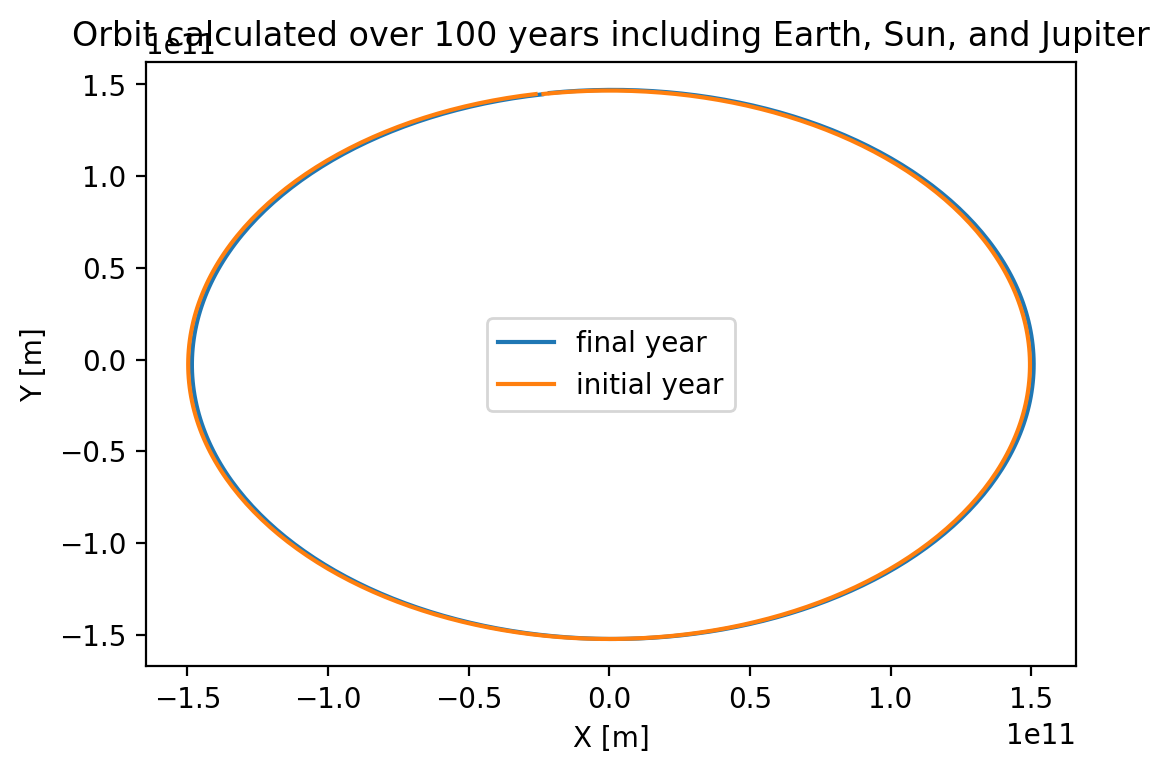

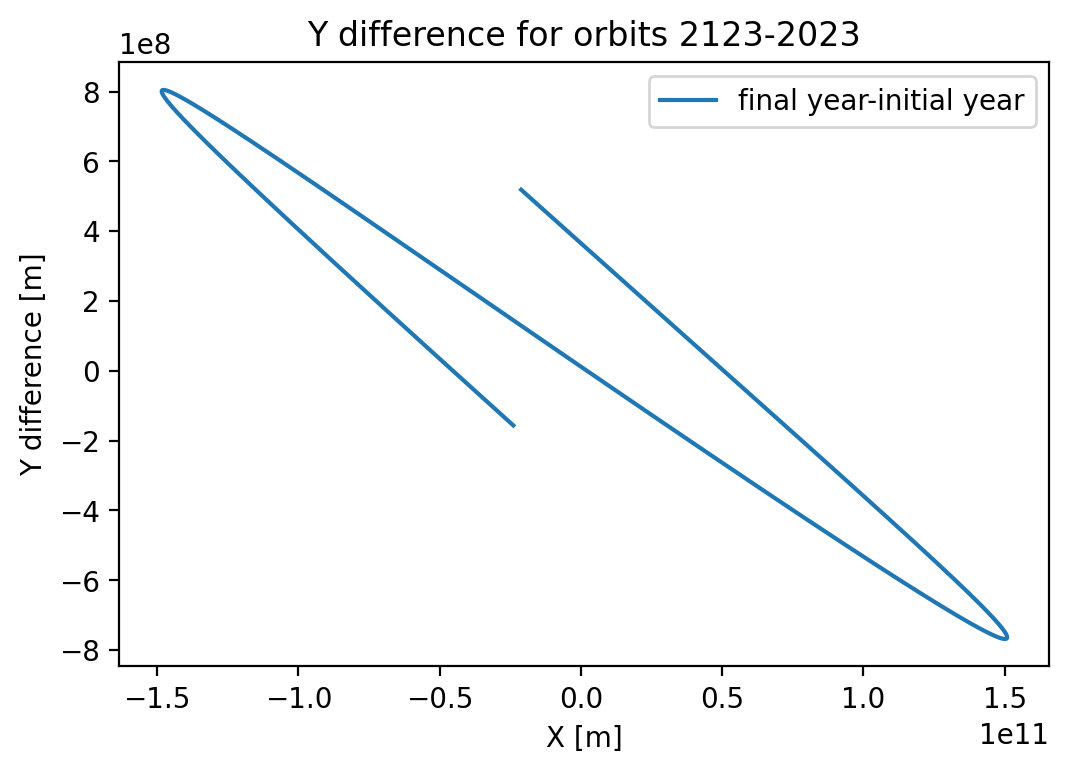

In [23]:
plt.plot(ephJ.y[0,-365:],ephJ.y[1,-365:],label='final year')
plt.plot(ephJ.y[0,0:365],ephJ.y[1,0:365],label='initial year')
plt.title("Orbit calculated over 100 years including Earth, Sun, and Jupiter")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend()
plt.show()
plt.plot(ephJ.y[0,-365:],ephJ.y[1,-365:]-ephJ.y[1,0:365],label='final year-initial year')
#plt.plot(ephJ.y[0,0:365],ephJ.y[1,0:365],label='initial year')
plt.title("Y difference for orbits 2123-2023")
plt.xlabel("X [m]")
plt.ylabel("Y difference [m]")
plt.legend()
plt.show()

### Validation:  Energy and Angular Momentum

We calculate the total energy and angular momentum, and see how much it changes in 100 years.

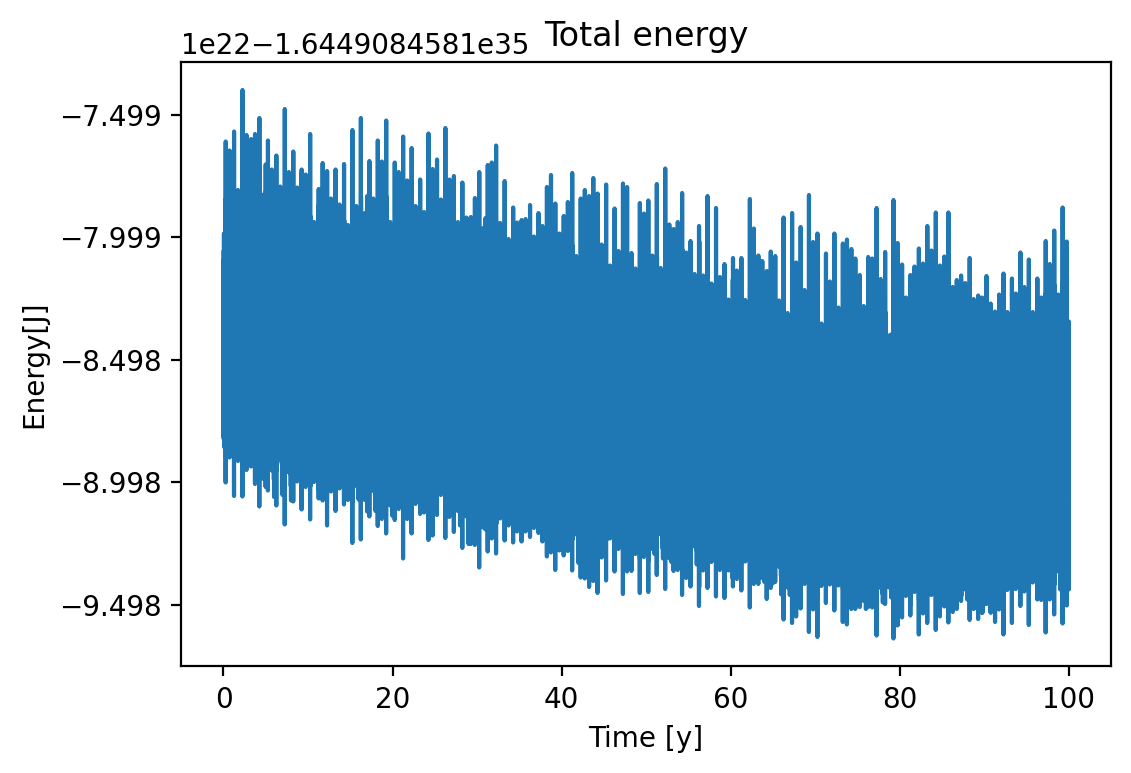

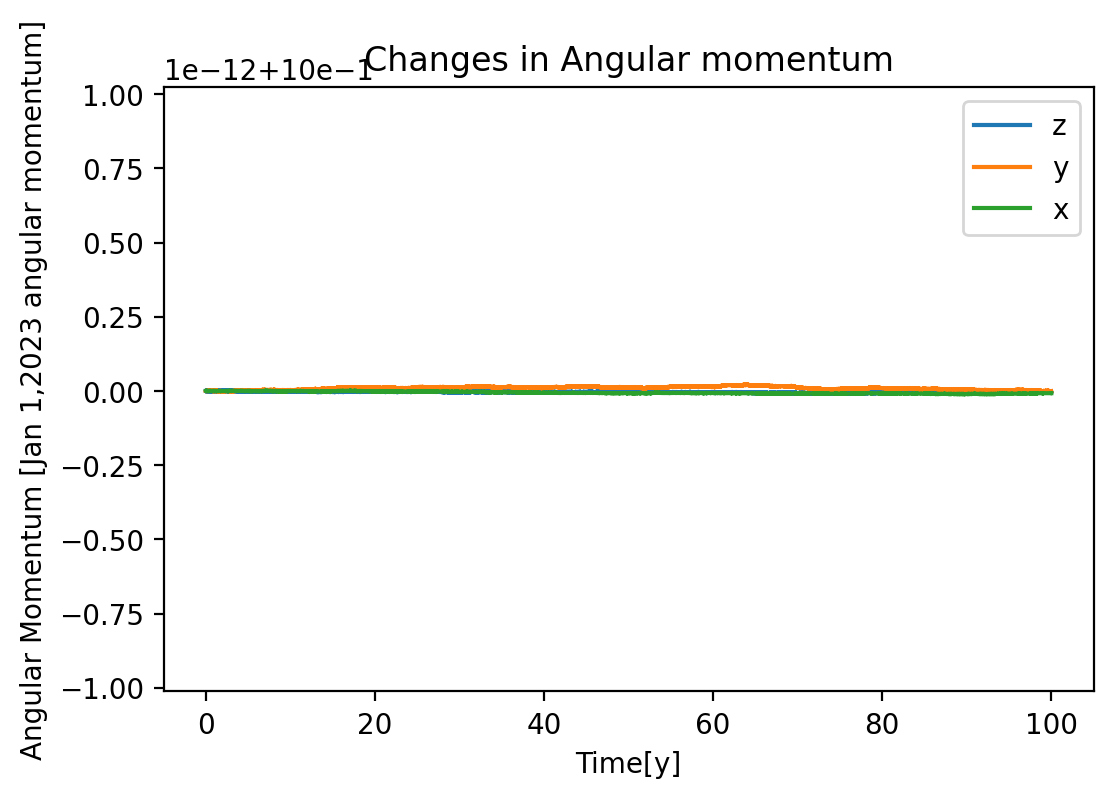

In [24]:

from scipy.constants import G

year=ephJ.t/spy
je=ephJ.y.reshape(4,3,-1)
xearth=je[0,:,:] #so xes has 3 rows and n columns
vearth=je[1,:,:]
xjupiter=je[2,:,:]
vjupiter=je[3,:,:]
xsun=-(xearth*GMEarth+xjupiter*GMJupiter)/GMSun
vsun=-(vearth*GMEarth+vjupiter*GMJupiter)/GMSun
xearth_sun=xearth-xsun
xjupiter_sun=xjupiter-xsun
xearth_jupiter=xearth-xjupiter
deS=np.linalg.norm(xearth_sun,axis=0)
dJS=np.linalg.norm(xjupiter_sun,axis=0)
deJ=np.linalg.norm(xearth_jupiter,axis=0)
en=GMEarth/G*(0.5*np.linalg.norm(vearth,axis=0)**2-GMSun/deS-GMJupiter/deJ)
enJ=GMJupiter/G*(0.5*(np.linalg.norm(vjupiter,axis=0)**2)-GMSun/dJS)
enS=GMSun/G*(0.5*(np.linalg.norm(vsun,axis=0)**2))
energy=en+enJ+enS
L=(GMEarth/G*np.cross(xearth,vearth,axis=0)+GMJupiter/G*np.cross(xjupiter,vjupiter,axis=0)+
           GMSun/G*np.cross(xsun,vsun,axis=0))


plt.plot(year[::],energy[::])
plt.title("Total energy")
plt.xlabel("Time [y]")
plt.ylabel("Energy[J]")
plt.show()
plt.title("Changes in Angular momentum")
plt.plot(year[::],L[2,::]/L[2,0],label='z')
plt.plot(year[::],L[1,::]/L[1,0],label='y')
plt.plot(year[::],L[0,::]/L[0,0],label='x')
plt.xlabel("Time[y]")
plt.ylabel("Angular Momentum [Jan 1,2023 angular momentum]")
plt.legend()
plt.show()

### Consider the integration method and the tolerance fed into solve_ivp

The default integrator in solve_ivp is a 5 order Runge-kutta.  There is also a 7 order available, DOP853.  Let's investigate how precision and integration time change with the different algorithms and precision.  When we are doing long calculations this is often worthwhile. 

In [25]:
def test(method,tolerance,solution=0):
    cpuT0=time.process_time()
    if solution==0:
        ephJ = solve_ivp(dvdtJ,(0,t), y0,t_eval=tlist,rtol=tolerance,method=method)
    else:
        ephJ=solution
    elapsedTime=time.process_time()-cpuT0
    
    year=ephJ.t/spy
    je=ephJ.y.reshape(4,3,-1)
    xearth=je[0,:,:] #so xes has 3 rows and n columns
    vearth=je[1,:,:]
    xjupiter=je[2,:,:]
    vjupiter=je[3,:,:]
    xsun=-(xearth*GMEarth+xjupiter*GMJupiter)/GMSun
    vsun=-(vearth*GMEarth+vjupiter*GMJupiter)/GMSun
    xearth_sun=xearth-xsun
    xjupiter_sun=xjupiter-xsun
    xearth_jupiter=xearth-xjupiter
    deS=np.linalg.norm(xearth_sun,axis=0)
    dJS=np.linalg.norm(xjupiter_sun,axis=0)
    deJ=np.linalg.norm(xearth_jupiter,axis=0)
    en=GMEarth/G*(0.5*np.linalg.norm(vearth,axis=0)**2-GMSun/deS-GMJupiter/deJ)
    enJ=GMJupiter/G*(0.5*(np.linalg.norm(vjupiter,axis=0)**2)-GMSun/dJS)
    enS=GMSun/G*(0.5*(np.linalg.norm(vsun,axis=0)**2))
    energy=en+enJ+enS
    L=(GMEarth/G*np.cross(xearth,vearth,axis=0)+GMJupiter/G*np.cross(xjupiter,vjupiter,axis=0)+
           GMSun/G*np.cross(xsun,vsun,axis=0))
    return(ephJ,elapsedTime,energy,L,method,tolerance)

results=[]
results.append(test('RK45',1e-12))
results.append(test('RK45',1e-13))
results.append(test('DOP853',1e-12))
results.append(test('DOP853',1e-13))

method=RK45, tolerance=1e-12, elapsed time=10.227819799999992s
method=RK45, tolerance=1e-13, elapsed time=14.971495800000014s
method=DOP853, tolerance=1e-12, elapsed time=2.601401199999998s
method=DOP853, tolerance=1e-13, elapsed time=3.34429879999999s


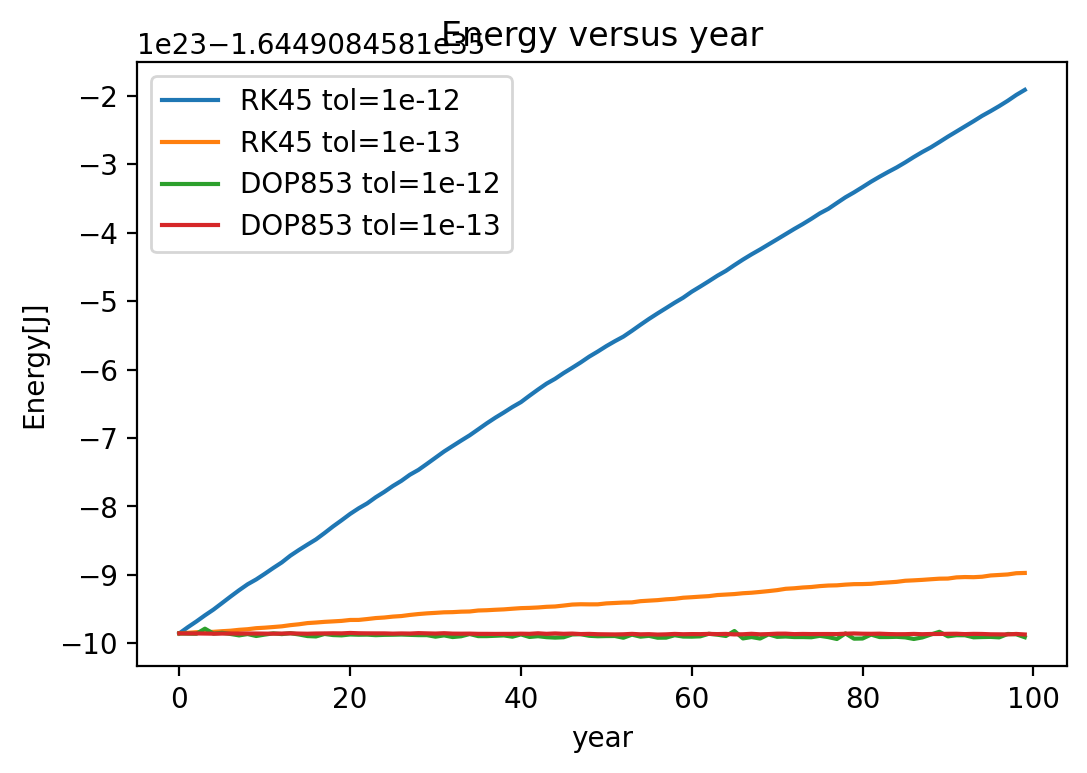

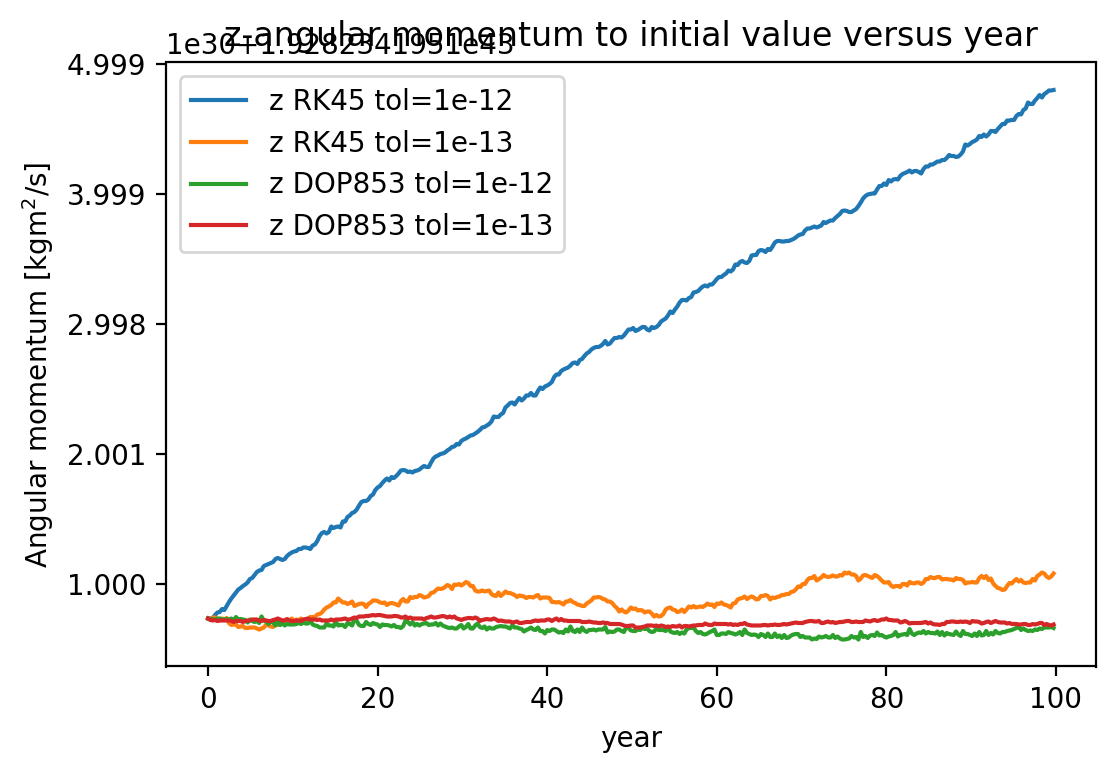

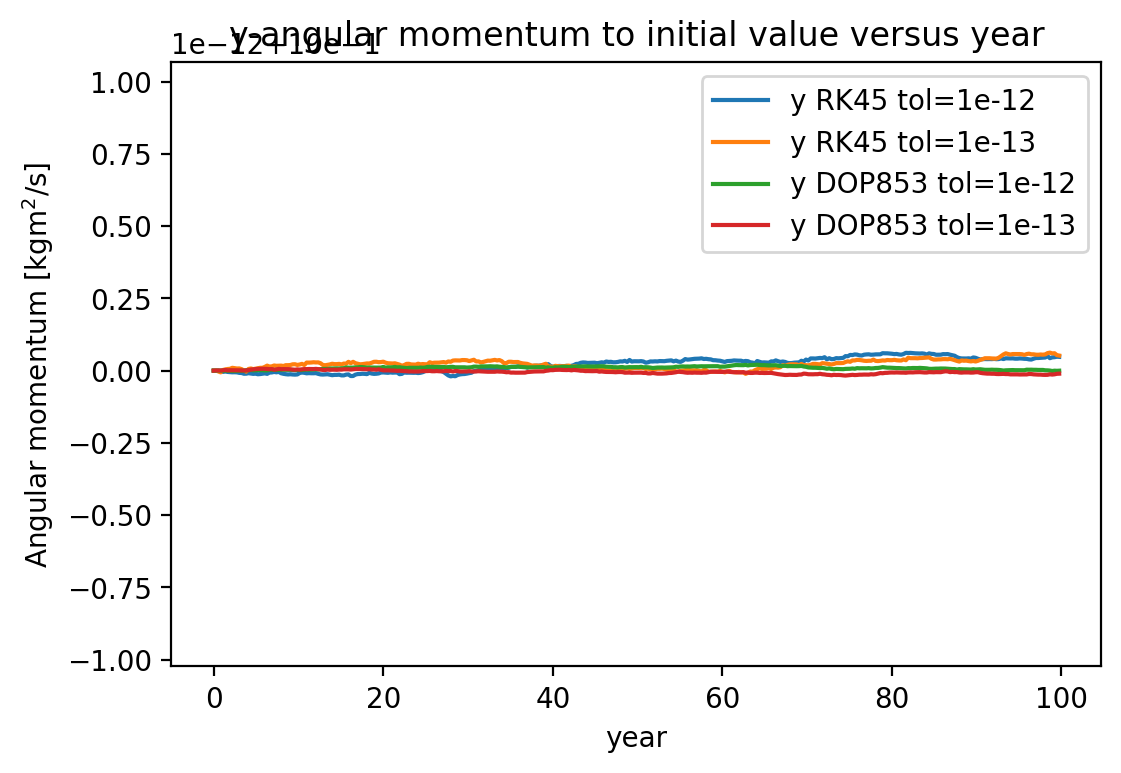

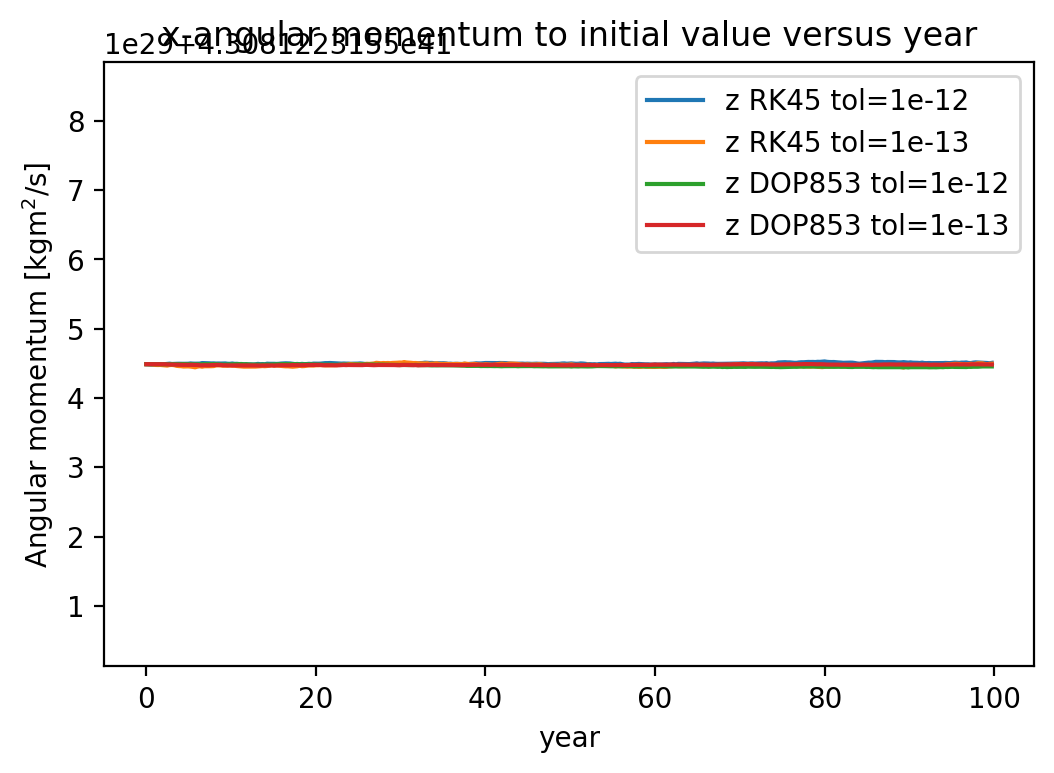

In [26]:
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    print(f'method={method}, tolerance={tolerance}, elapsed time={elapsedTime}s')
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::365],energy[::365],label=f'{method} tol={tolerance}')
    
plt.title('Energy versus year')
plt.xlabel('year')
plt.ylabel('Energy[J]')
plt.legend()
plt.show()
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::100],L[2,::100],label=f'z {method} tol={tolerance}')
plt.title('z-angular momentum to initial value versus year')
plt.xlabel('year')
plt.ylabel('Angular momentum [kgm$^2$/s]')
plt.legend()
plt.show()
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::100],L[1,::100]/L[1,0],label=f'y {method} tol={tolerance}')
plt.title('y-angular momentum to initial value versus year')
plt.xlabel('year')
plt.ylabel('Angular momentum [kgm$^2$/s]')
plt.legend()
plt.show()
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::100],L[0,::100],label=f'z {method} tol={tolerance}')
plt.title('x-angular momentum to initial value versus year')
plt.xlabel('year')
plt.ylabel('Angular momentum [kgm$^2$/s]')
plt.legend()
plt.show()


Clearly, we gain considerably- both in running time and precision, by using the DOP853 algorithm.  Our uncertainties look to be about a part in 1e12 after 100 years.  I integrated for 1M years into the future on my desktop ( which took a little less than 6 hours of clock time).    

### Ellipses

In a given year, we think about the earth's orbit as an ellipse.  It isn't really when we have three body forces (in fact, the plane even shifts).  However, we know it is pretty close to an ellipse.  

A couple of points of interest, though.  If we try to find an ellipse with respect to the center of mass- we can't, especially when we look at long times- because the ellipse is really the solution for the earth-sun system without Jupiter.  

What we need to do is to go back to the earth-sun system, define a reference plane using the average angular momentum during the year and defining a plane perpendicular to that angular momentum.   We then get 5 x-y points (projecting into that plane-- ie.  ignoring the z-values) that we will then solve to find the major and minor axis.

It is also of interest to find the dot product between the spin-axis of the earth and the angular momentum.  In the coordinates horizon chooses, the earth's axis is in the y-z plane, and the tilt angle is given in Horizons.  

To find the ellipse, we solve the equations:
$$
Ax^2+Bxy+Cy^2+Dx+Ey=1  $$

One can then find the angle of rotation of the ellipse by $\tan{2\alpha}=\frac{B}{A-C}$ and then use the equations 
$$\begin{align}
 A+C&= \frac{1}{a^2}+\frac{1}{b^2}\\
 A-C&= \cos{2\alpha} \left(\frac{1}{a^2}-\frac{1}{b^2}\right)
\end{align}
$$
to find the semimajor axes $a$ and semiminor axis $b$.

We rewrite our equation in terms of a matrix multiplication:
$$\left(\begin{array}{ccccc}
x_i^2 &x_iy_i&y_i^2&x_i&y_i\\
x_{i+1}^2 &x_{i+1}y_{i+1}&y_{i+1}^2&x_{i+1}&y_{i+1}\\
x_{i+2}^2 &x_{i+2}y_{i+2}&y_{i+2}^2&x_{i+2}&y_{i+2}\\
x_{i+3}^2 &x_{i+3}y_{i+3}&y_{i+3}^2&x_{i+3}&y_{i+3}\\
x_{i+4}^2 &x_{i+4}y_{i+4}&y_{i+4}^2&x_{i+4}&y_{i+4}
 \end{array}\right)\left(\begin{array}{c}
A\\
B\\
C\\
D\\
E\end{array}\right)=\left(\begin{array}{c}1\\1\\1\\1\\1\end{array}\right)$$
so that
$$\left(\begin{array}{c}
A\\
B\\
C\\
D\\
E\end{array}\right)=\left(\begin{array}{ccccc}
x_i^2 &x_iy_i&y_i^2&x_i&y_i\\
x_{i+1}^2 &x_{i+1}y_{i+1}&y_{i+1}^2&x_{i+1}&y_{i+1}\\
x_{i+2}^2 &x_{i+2}y_{i+2}&y_{i+2}^2&x_{i+2}&y_{i+2}\\
x_{i+3}^2 &x_{i+3}y_{i+3}&y_{i+3}^2&x_{i+3}&y_{i+3}\\
x_{i+4}^2 &x_{i+4}y_{i+4}&y_{i+4}^2&x_{i+4}&y_{i+4}
 \end{array}\right)^{-1}\left(\begin{array}{c}1\\1\\1\\1\\1\end{array}\right)$$



In [27]:
with open("ephJM.pickle","rb") as f:
    ephJ=pickle.load(f)
results=[test(1e-13,'DOP853',ephJ)]
je=ephJ.y.reshape(4,3,-1)
xs=-(je[0]*GMEarth+je[2]*GMJupiter)/GMSun
vs=-(je[1]*GMEarth+je[3]*GMJupiter)/GMSun
xes=je[0]-xs #so xes has 3 rows and n columns
ves=je[1]-vs


method=1e-13, tolerance=DOP853, elapsed time=4.39999999457541e-06s


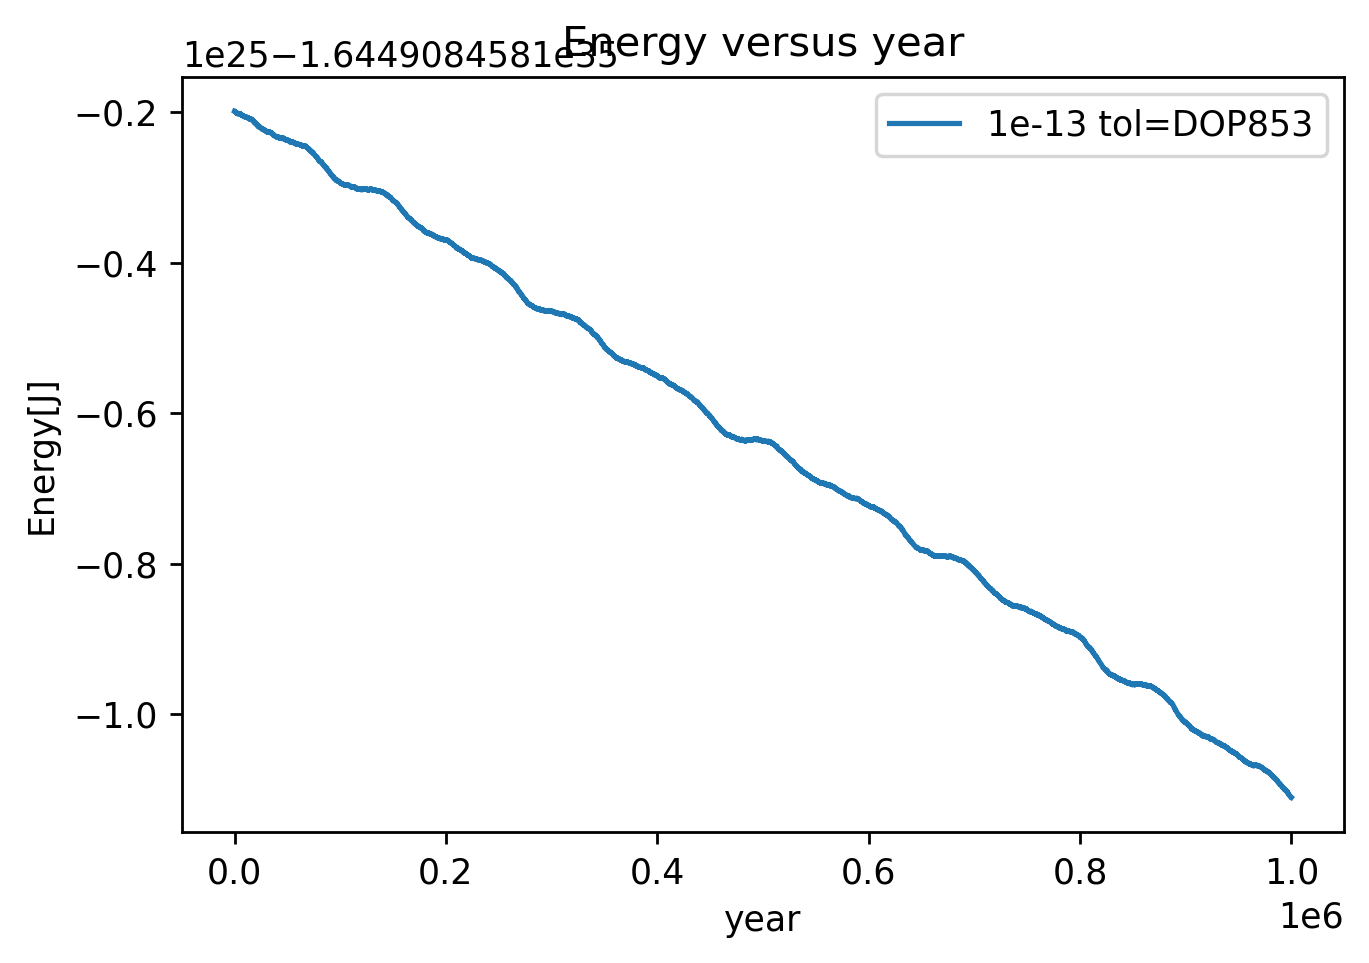

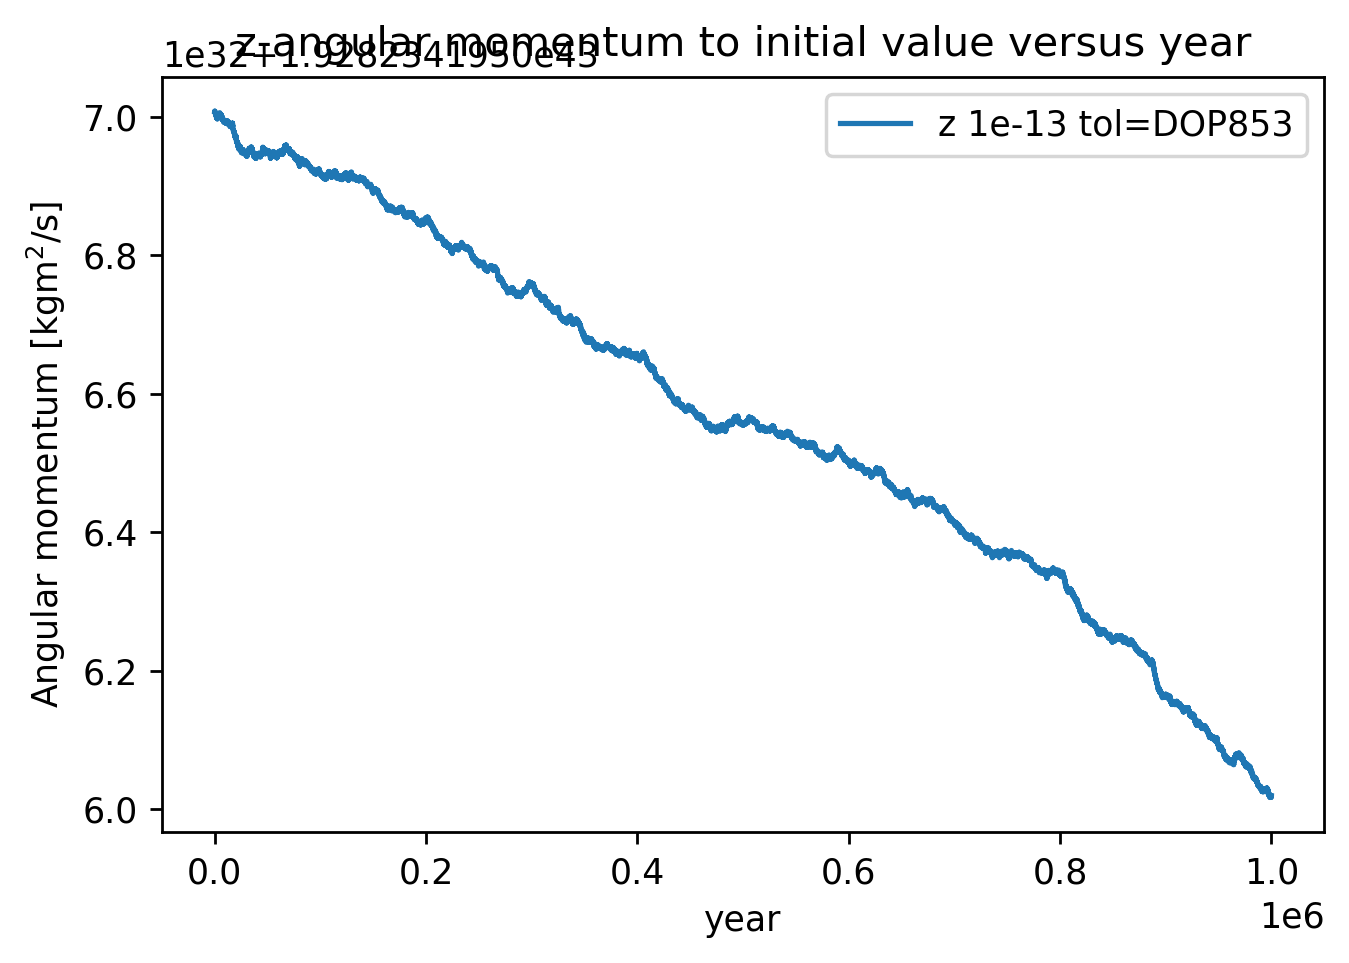

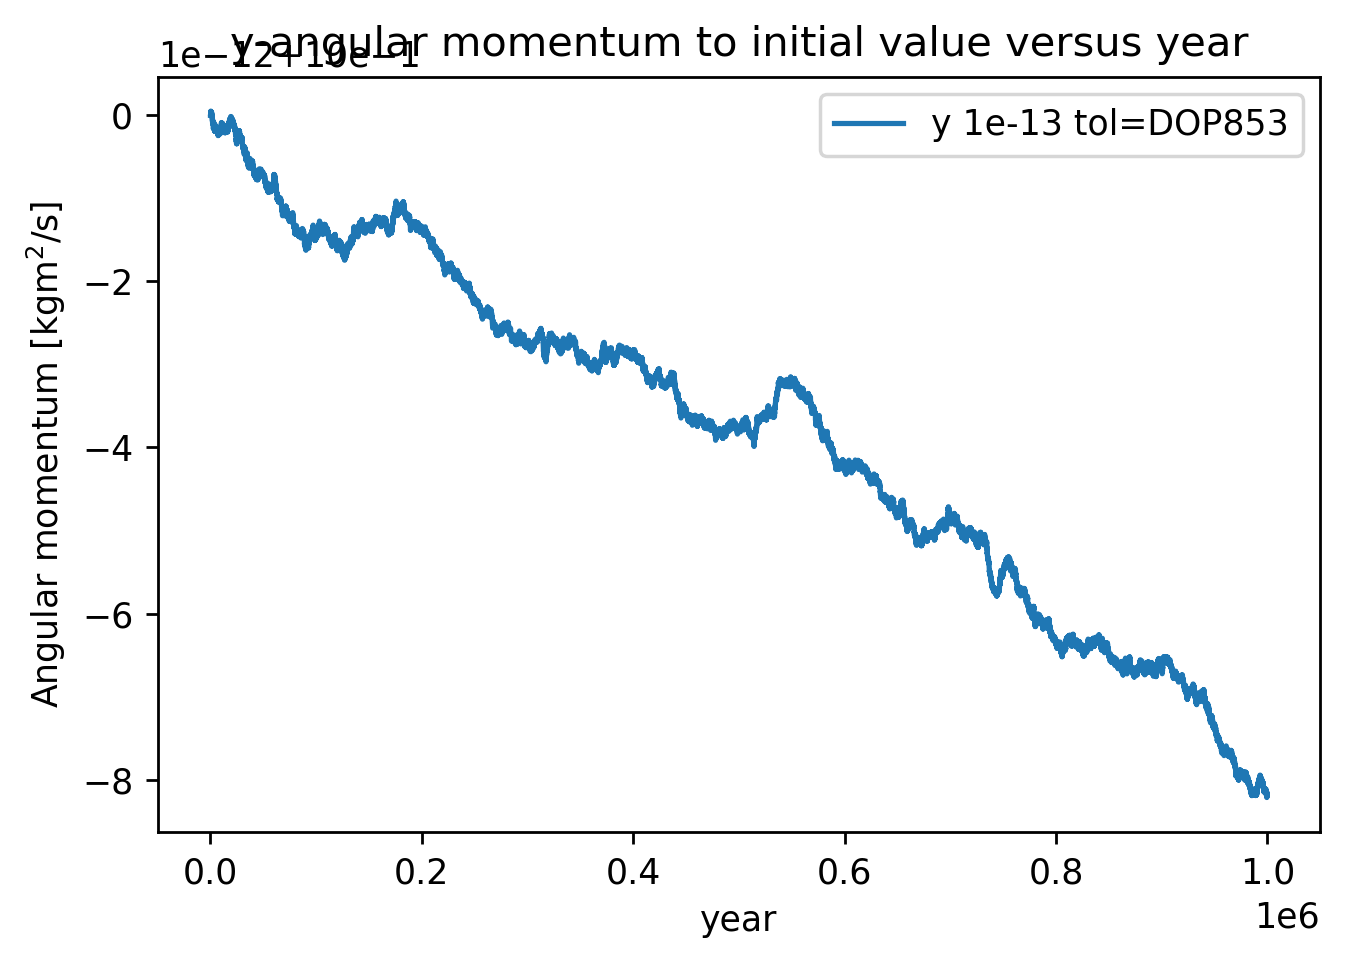

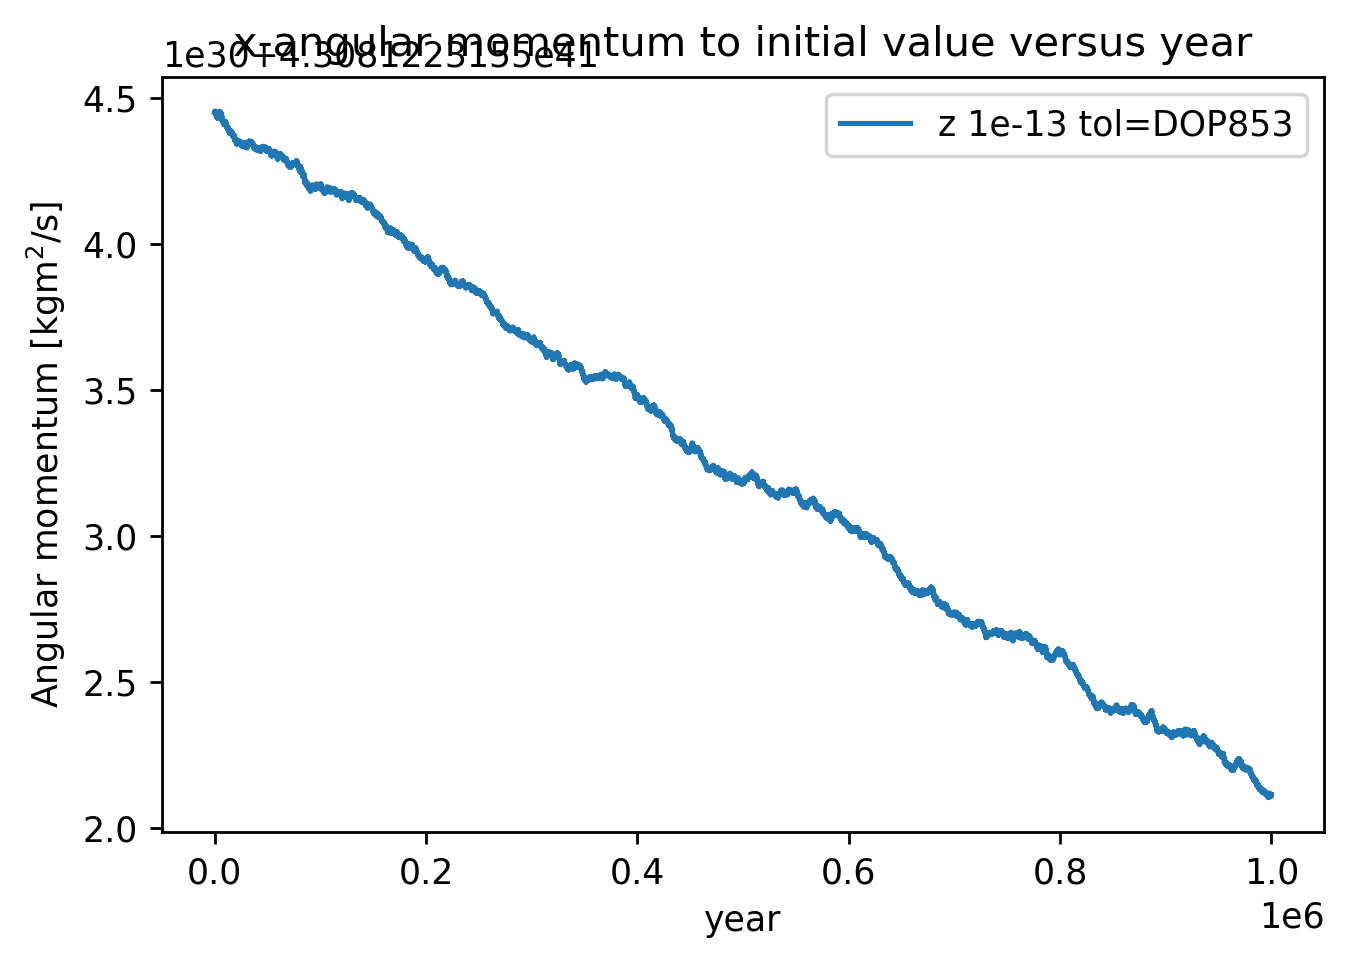

In [13]:
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    print(f'method={method}, tolerance={tolerance}, elapsed time={elapsedTime}s')
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::365],energy[::365],label=f'{method} tol={tolerance}')
    
plt.title('Energy versus year')
plt.xlabel('year')
plt.ylabel('Energy[J]')
plt.legend()
plt.show()
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::100],L[2,::100],label=f'z {method} tol={tolerance}')
plt.title('z-angular momentum to initial value versus year')
plt.xlabel('year')
plt.ylabel('Angular momentum [kgm$^2$/s]')
plt.legend()
plt.show()
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::100],L[1,::100]/L[1,0],label=f'y {method} tol={tolerance}')
plt.title('y-angular momentum to initial value versus year')
plt.xlabel('year')
plt.ylabel('Angular momentum [kgm$^2$/s]')
plt.legend()
plt.show()
for r in results:
    ephJ,elapsedTime,energy,L,method,tolerance =r
    year=ephJ.t/spy
    plt.plot(year[::100],L[0,::100],label=f'z {method} tol={tolerance}')
plt.title('x-angular momentum to initial value versus year')
plt.xlabel('year')
plt.ylabel('Angular momentum [kgm$^2$/s]')
plt.legend()
plt.show()


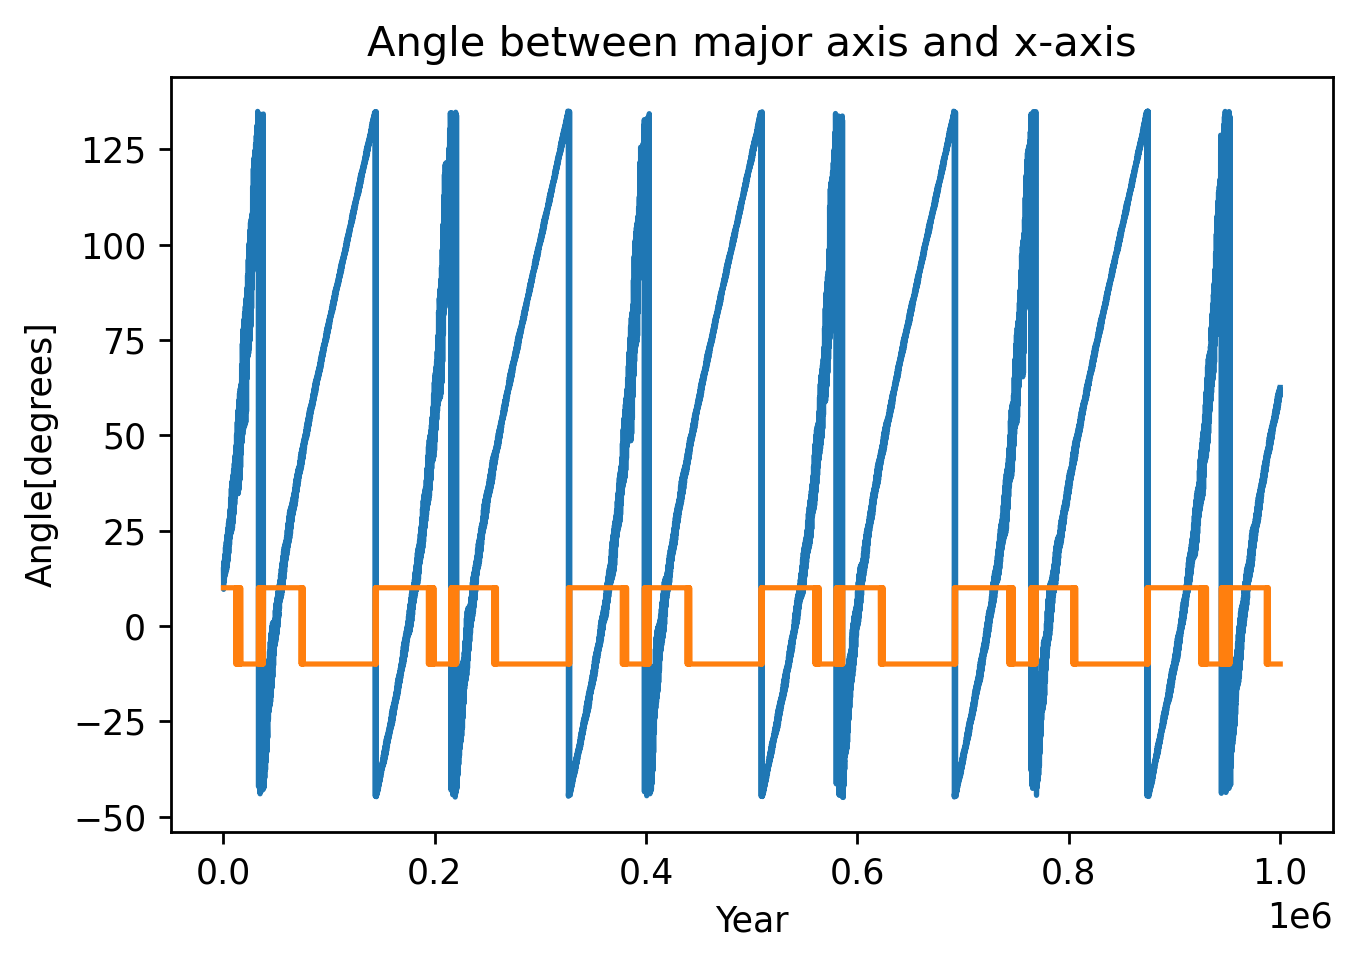

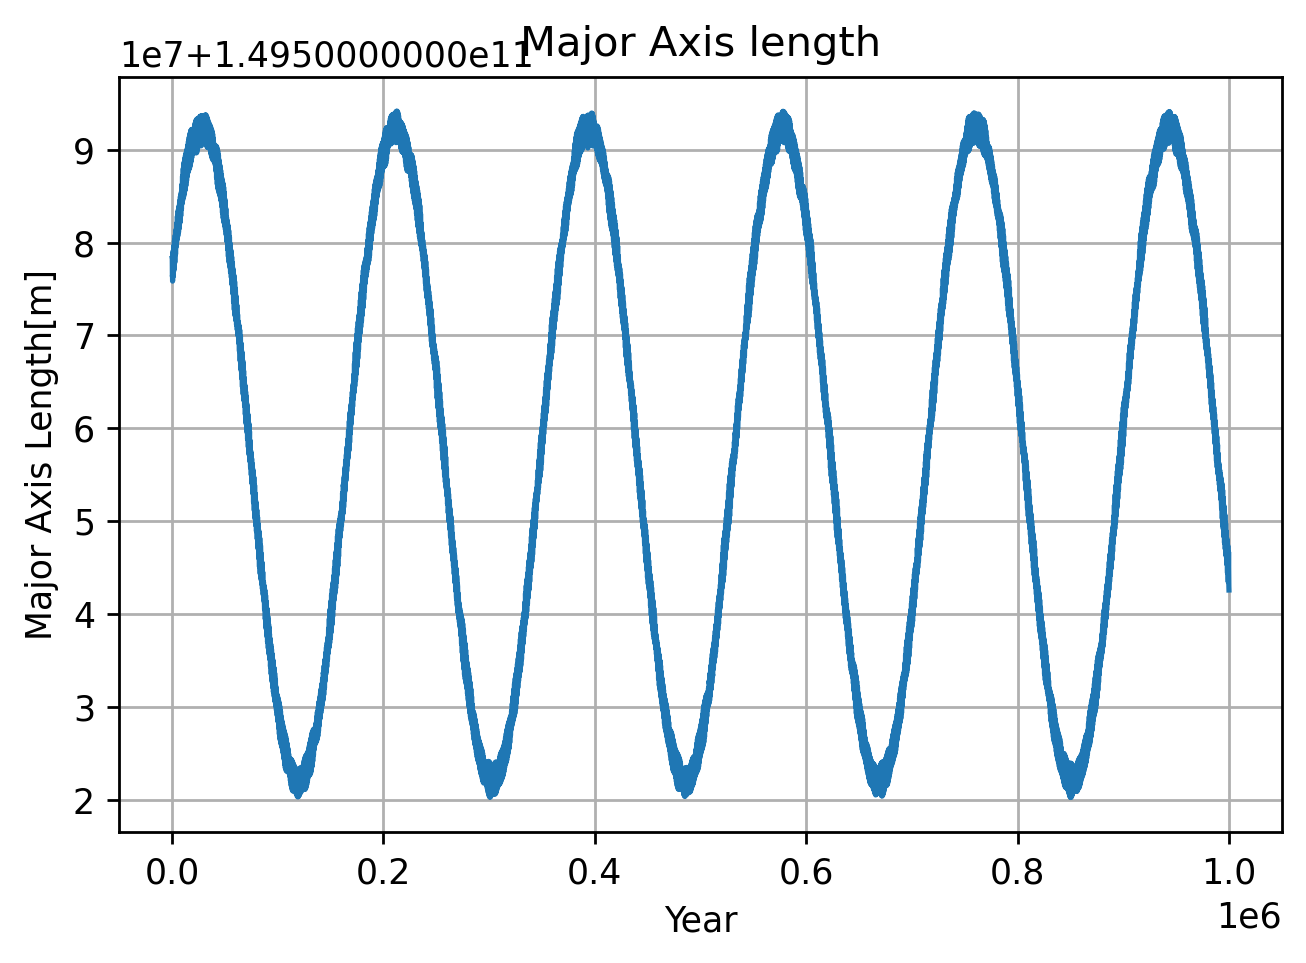

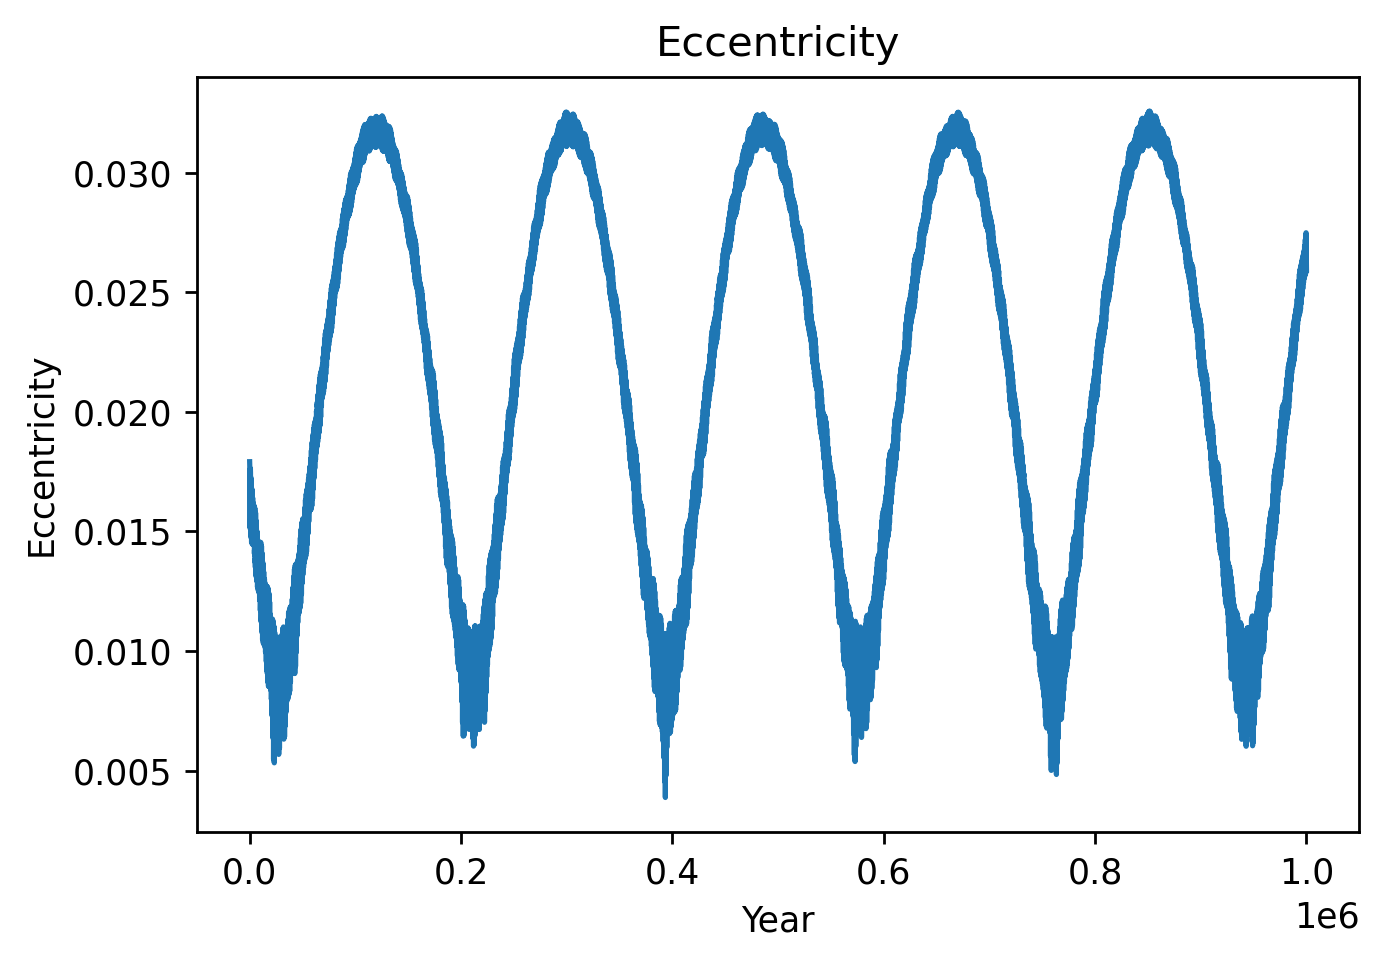

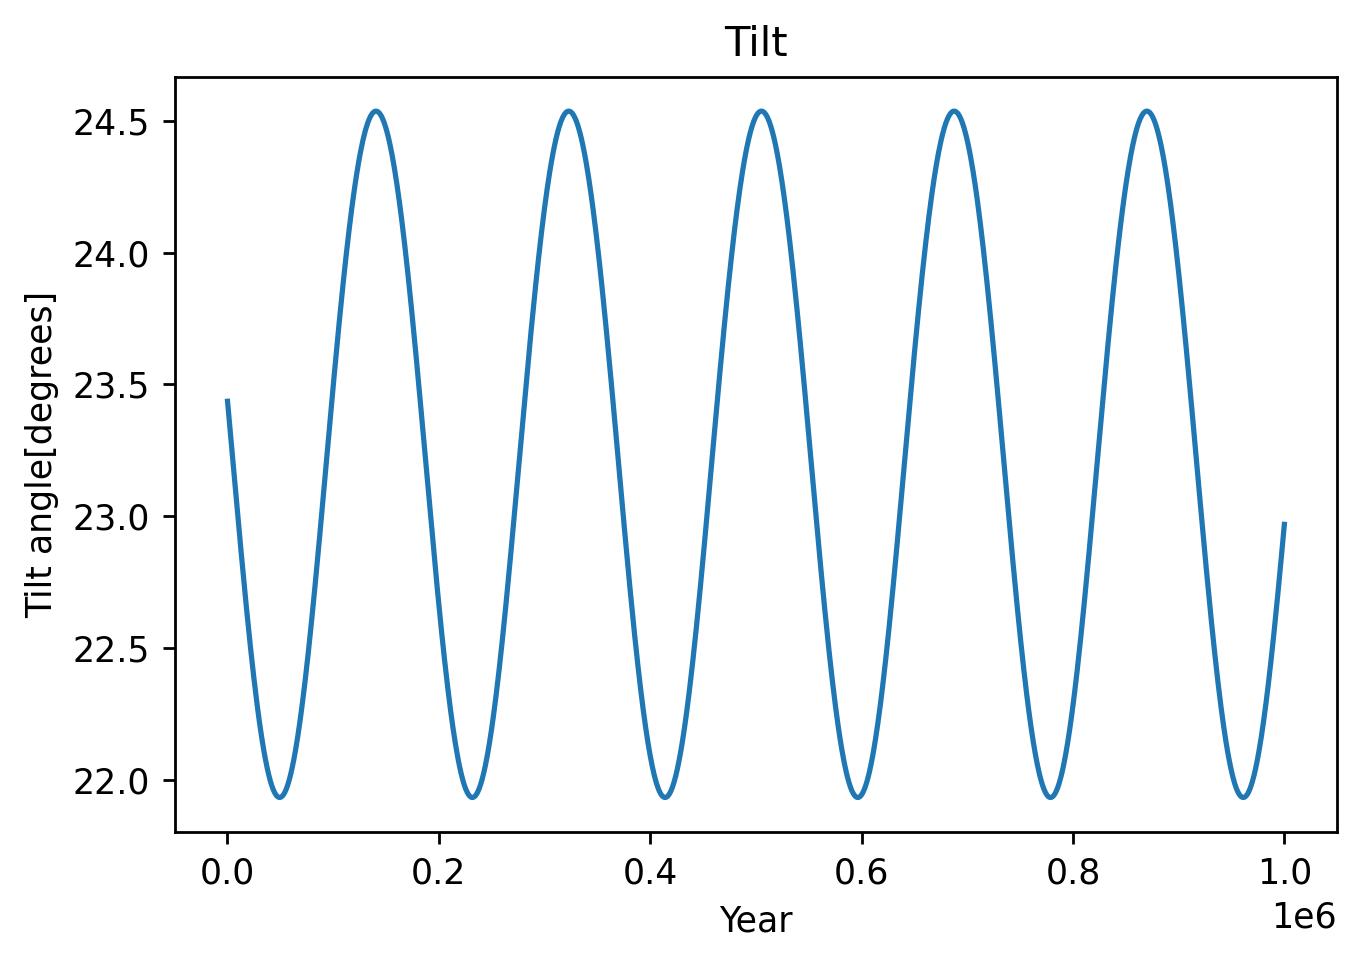

In [14]:
tiltAngle=np.radians(23.4392911)
earthAxis=np.array([0,np.sin(tiltAngle),np.cos(tiltAngle)])
xlist=xes.transpose().reshape(-1,10,3) #so now the index is [year][period 0-9][x,y,z]
vlist=ves.transpose().reshape(-1,10,3)
year=[]
alpha=[]
tilt=[]
majorAxis=[]
minorAxis=[]
eccentricity=[]
majFirst=[]
y=0
ystep=100
col=np.ones((5,1))
for ix in range(0,len(xlist),ystep):
    L=np.mean(np.cross(xlist[ix],vlist[ix]),axis=0)
#    print(L)
    k=L/np.linalg.norm(L)
    i=np.array([1,0,0])-k[0]*k  #xhat-(k*xhat)*k -- notice that this is perpendicular to k
    i=i/np.linalg.norm(i)  #unit vector
    j=np.cross(k,i)
    matrix=np.array([i,j,k])  #make a 3x3 matrix to do coordinate transform
    xes2=np.array([matrix@a for a in xlist[ix]])
    ves2=np.array([matrix@a for a in vlist[ix]])
#    print(ves2)
    M=np.array([xes2[::2,0]**2, xes2[::2,0]*xes2[::2,1],xes2[::2,1]**2,
                  xes2[::2,0],xes2[::2,1]]).transpose()

    InverseM=np.linalg.inv(M)
    A,B,C,D,E=np.dot(InverseM,col)
    theta2=np.arctan(B/(A-C))
    a=np.sqrt(2.0/(A+C+(A-C)/np.cos(theta2)))
    b=np.sqrt(2.0/(A+C-(A-C)/np.cos(theta2)))
    xc=(B*E+2*C*D)/(B*B-4*A*C)
    yc=(D+2*A*xc)/B
    y=y+ystep
    year.append(y)  #corresponds to step in yearDat
    tilt.append(np.arccos(np.dot(k,earthAxis))*180.0/np.pi)
    if b>a:
        majorAxis.append(b)
        minorAxis.append(a)
        eccentricity.append(np.sqrt(1-(a/b)**2))
        majFirst.append(10)
        alpha.append(theta2/2*180/np.pi)
    else:
        majorAxis.append(a)
        minorAxis.append(b)
        eccentricity.append(np.sqrt(1-(b/a)**2))
        majFirst.append(-10)
        alpha.append(theta2/2*180/np.pi+90)
plt.figure()
plt.title('Angle between major axis and x-axis')
plt.xlabel("Year")
plt.ylabel("Angle[degrees]")
plt.plot(year,alpha)
plt.plot(year,majFirst)
plt.show()
plt.title('Major Axis length')
plt.plot(year,majorAxis)
plt.xlabel("Year")
plt.ylabel("Major Axis Length[m]")
plt.grid()
plt.show()
plt.title('Eccentricity')
plt.plot(year,eccentricity)
plt.xlabel("Year")
plt.ylabel("Eccentricity")
plt.show()
plt.title('Tilt')
plt.plot(year,tilt)
plt.xlabel("Year")
plt.ylabel("Tilt angle[degrees]")
plt.show()


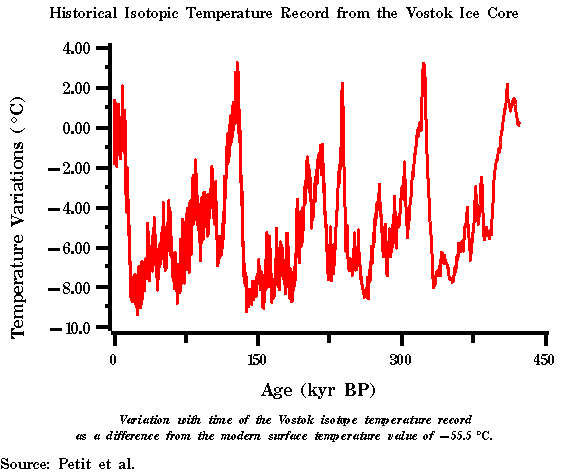

In [28]:
print(f"since we have 5.5 oscillations in 1M years the period is approximately {int(1e6/5.5/1000)*1000:3.0f} years.")

GMSaturn=37931206.234e9
print(f"The ratio of Saturn/Jupiter mass is {GMSaturn/GMJupiter:6.4}, so we could consider adding it as well.")

since we have 5.5 oscillations in 1M years the period is approximately 181000 years.
The ratio of Saturn/Jupiter mass is 0.2994, so we could consider adding it as well.


Clearly we don't have good agreement with just the Earth-Jupiter-Sun system, but it isn't obvious that the Vostok temperature record is completely planetary.  There are also effects on the orbit from Venus (which, although smaller, is closer) and from Saturn.  It isn't significantly different to add Venus and Saturn, but I don't think it is instructive at this point- all it does is add more terms into the integration.    